# Lab 8: Image Enhancement in Medical, Security, Satellite, Photo Restoration, and Biomedical Applications

This notebook demonstrates point operations, histogram equalization, and advanced contrast techniques for real-world scenarios.

## 1. Medical Image Enhancement: X-ray Contrast Improvement

Apply contrast stretching, log transformation, and histogram equalization. Plot histograms and write observations.

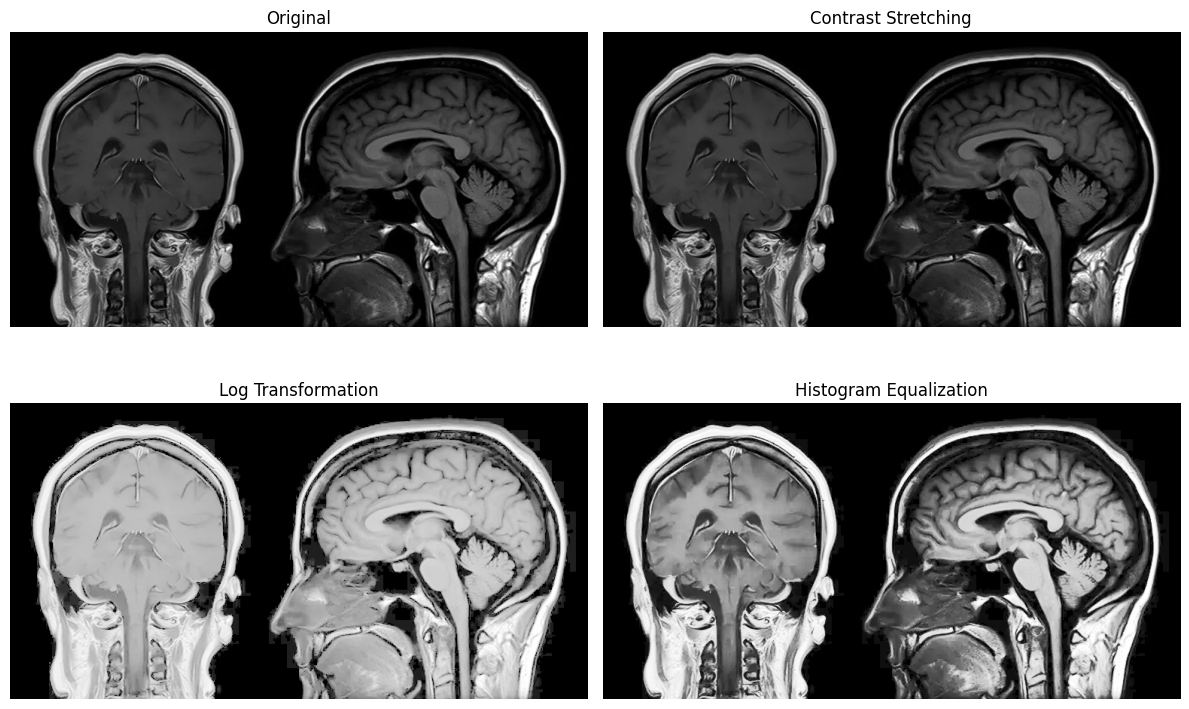

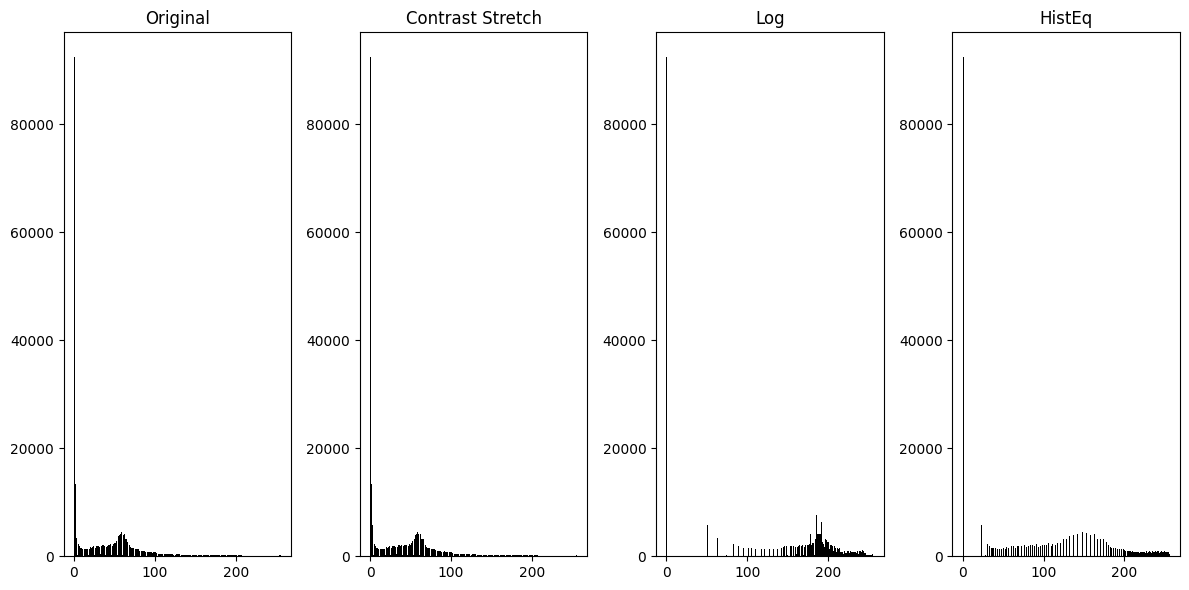

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load X-ray image (replace with your filename if needed)
img = cv2.imread('mri.jpeg', cv2.IMREAD_GRAYSCALE)
if img is None:
    raise Exception('Image not found!')

# Contrast stretching
min_val, max_val = np.min(img), np.max(img)
cs_img = ((img - min_val) / (max_val - min_val) * 255).astype(np.uint8)

# Log transformation
c = 255 / np.log(1 + np.max(img))
log_img = c * np.log(1 + img.astype(np.float32))
log_img = np.array(log_img, dtype=np.uint8)

# Histogram equalization
hist_eq_img = cv2.equalizeHist(img)

# Plot images
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(cs_img, cmap='gray')
plt.title('Contrast Stretching')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(log_img, cmap='gray')
plt.title('Log Transformation')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(hist_eq_img, cmap='gray')
plt.title('Histogram Equalization')
plt.axis('off')
plt.tight_layout()
plt.show()

# Plot histograms
plt.figure(figsize=(12,6))
for i, im in enumerate([img, cs_img, log_img, hist_eq_img]):
    plt.subplot(1,4,i+1)
    plt.hist(im.ravel(), bins=256, range=[0,256], color='black')
    plt.title(['Original','Contrast Stretch','Log','HistEq'][i])
plt.tight_layout()
plt.show()

### Observations: Medical Image Enhancement

- **Contrast stretching** improves visibility of bone structures by expanding the intensity range, making fractures more distinguishable.
- **Log transformation** enhances low-intensity details, useful for faint features but may compress bright regions.
- **Histogram equalization** provides the most uniform contrast, making overall structures clearer, but may amplify noise in very dark/bright areas.
- For diagnostic quality, histogram equalization is often preferred, but contrast stretching/log transform can be useful for specific regions.

## 2. Security Surveillance Enhancement: Low-Light Face Visibility

Apply gamma correction and histogram equalization to a low-light image. Compare results and discuss trade-offs.

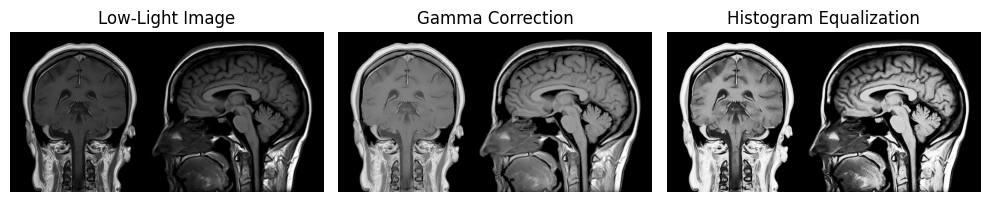

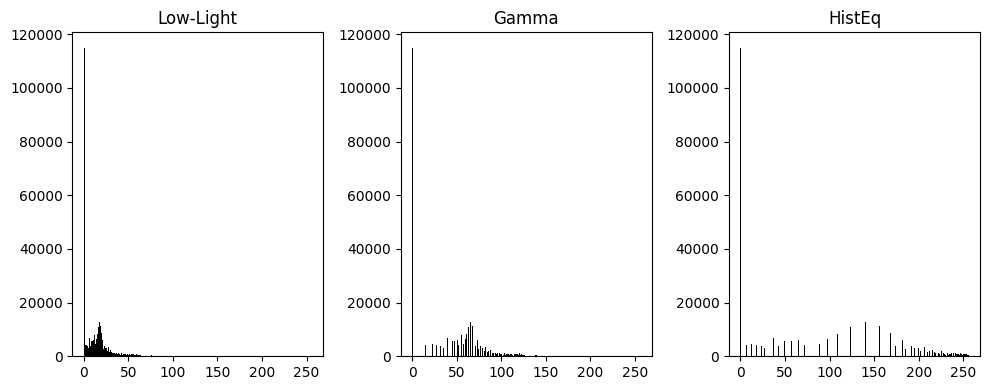

In [2]:
# Simulate a low-light grayscale image (use MRI as example)
img = cv2.imread('mri.jpeg', cv2.IMREAD_GRAYSCALE)
if img is None:
    raise Exception('Image not found!')
low_light = (img * 0.3).astype(np.uint8)

# Gamma correction (brighten dark regions)
gamma = 2.0
gamma_corr = np.array(255 * (low_light / 255) ** (1/gamma), dtype=np.uint8)

# Histogram equalization
hist_eq = cv2.equalizeHist(low_light)

# Plot images
plt.figure(figsize=(10,6))
plt.subplot(1,3,1)
plt.imshow(low_light, cmap='gray')
plt.title('Low-Light Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(gamma_corr, cmap='gray')
plt.title('Gamma Correction')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hist_eq, cmap='gray')
plt.title('Histogram Equalization')
plt.axis('off')
plt.tight_layout()
plt.show()

# Plot histograms
plt.figure(figsize=(10,4))
for i, im in enumerate([low_light, gamma_corr, hist_eq]):
    plt.subplot(1,3,i+1)
    plt.hist(im.ravel(), bins=256, range=[0,256], color='black')
    plt.title(['Low-Light','Gamma','HistEq'][i])
plt.tight_layout()
plt.show()

### Observations: Security Surveillance Enhancement

- **Gamma correction** brightens dark regions without over-saturating bright areas, improving facial visibility in low-light images.
- **Histogram equalization** increases overall contrast but may introduce noise or over-brighten some regions.
- For facial identification, gamma correction is often preferred for natural enhancement, while histogram equalization is useful for general contrast improvement.
- Trade-off: Gamma preserves details in shadows, histogram equalization may lose subtle features in very dark/bright areas.

## 3. Satellite Image Contrast Correction

Apply contrast stretching and histogram equalization to a washed-out satellite image. Analyze differentiation between vegetation and barren land.

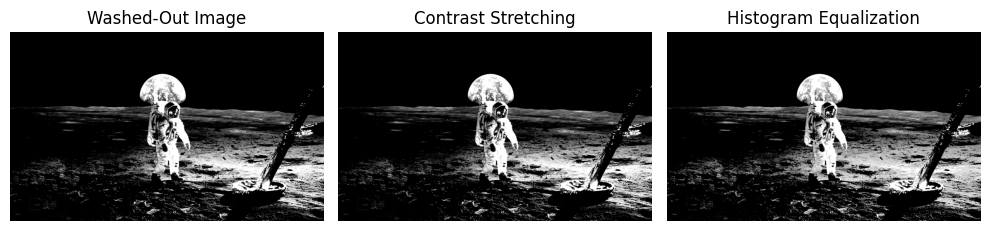

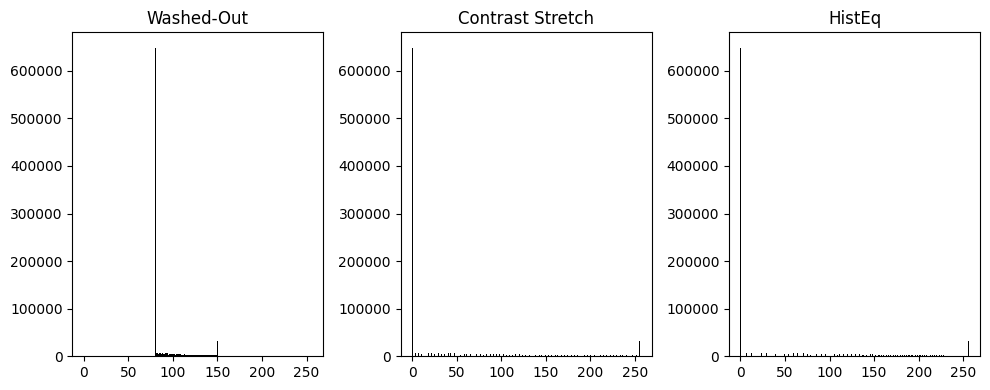

In [4]:
# Load satellite image (replace with your filename if needed)
sat_img = cv2.imread('moon.webp', cv2.IMREAD_GRAYSCALE)
if sat_img is None:
    raise Exception('Image not found!')

# Simulate washed-out effect (intensities 80-150)
sat_img = np.clip(sat_img, 80, 150)

# Contrast stretching
cs_sat = ((sat_img - 80) / (150 - 80) * 255).astype(np.uint8)

# Histogram equalization
hist_eq_sat = cv2.equalizeHist(sat_img)

# Plot images
plt.figure(figsize=(10,6))

plt.subplot(1,3,1)
plt.imshow(sat_img, cmap='gray')
plt.title('Washed-Out Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(cs_sat, cmap='gray')
plt.title('Contrast Stretching')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hist_eq_sat, cmap='gray')
plt.title('Histogram Equalization')
plt.axis('off')
plt.tight_layout()
plt.show()

# Plot histograms
plt.figure(figsize=(10,4))
for i, im in enumerate([sat_img, cs_sat, hist_eq_sat]):
    plt.subplot(1,3,i+1)
    plt.hist(im.ravel(), bins=256, range=[0,256], color='black')
    plt.title(['Washed-Out','Contrast Stretch','HistEq'][i])
plt.tight_layout()
plt.show()

### Observations: Satellite Image Contrast Correction

- **Contrast stretching** redistributes pixel intensities, making differences between vegetation and barren land more visible.
- **Histogram equalization** enhances global contrast, but may exaggerate noise or small features.
- For agricultural analysis, contrast stretching is often preferred for controlled enhancement, while histogram equalization is useful for general contrast improvement.
- Visual and histogram analysis show better separation of land types after enhancement.

## 4. Digital Photo Restoration: Archival Enhancement

Apply piecewise linear transformation and adaptive histogram equalization (CLAHE). Compare global histogram equalization vs CLAHE visually and numerically.

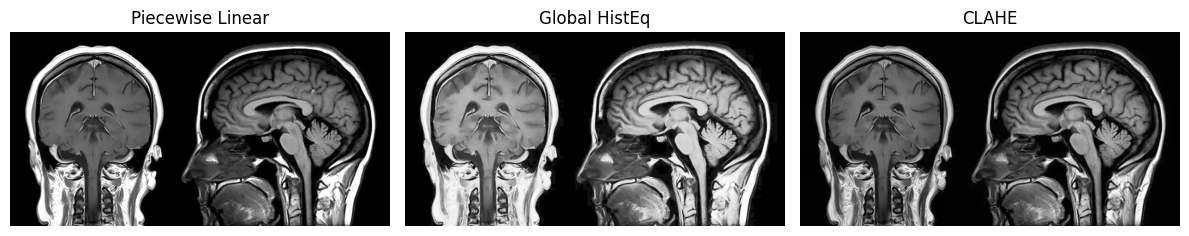

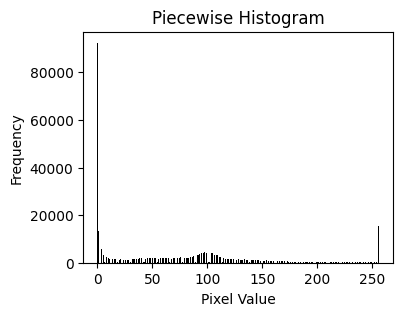

Piecewise: Mean=66.68, Std=73.93


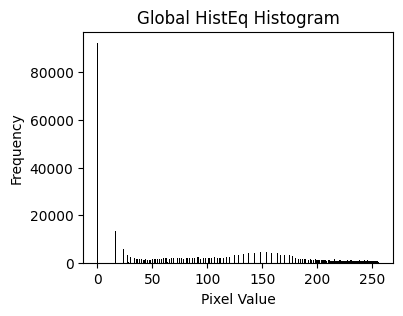

Global HistEq: Mean=89.66, Std=84.90


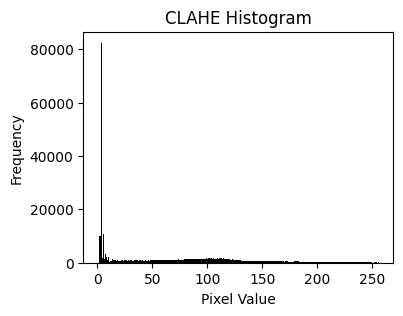

CLAHE: Mean=65.11, Std=64.77


In [5]:
# Simulate a scanned photo (use MRI as example)
photo = cv2.imread('mri.jpeg', cv2.IMREAD_GRAYSCALE)
if photo is None:
    raise Exception('Image not found!')

# Piecewise linear transformation: contrast stretching + thresholding
min_val, max_val = np.percentile(photo, [5, 95])
piecewise = np.clip((photo - min_val) / (max_val - min_val) * 255, 0, 255).astype(np.uint8)
piecewise[photo < min_val] = 0
piecewise[photo > max_val] = 255

# Global histogram equalization
glob_hist_eq = cv2.equalizeHist(photo)

# Adaptive histogram equalization (CLAHE)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
adapt_hist_eq = clahe.apply(photo)

# Plot images
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(piecewise, cmap='gray')
plt.title('Piecewise Linear')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(glob_hist_eq, cmap='gray')
plt.title('Global HistEq')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(adapt_hist_eq, cmap='gray')
plt.title('CLAHE')
plt.axis('off')
plt.tight_layout()
plt.show()

# Compare histograms, mean, std
for name, im in zip(['Piecewise','Global HistEq','CLAHE'], [piecewise, glob_hist_eq, adapt_hist_eq]):
    plt.figure(figsize=(4,3))
    plt.hist(im.ravel(), bins=256, range=[0,256], color='black')
    plt.title(f'{name} Histogram')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.show()
    print(f'{name}: Mean={np.mean(im):.2f}, Std={np.std(im):.2f}')

### Observations: Digital Photo Restoration

- **Piecewise linear transformation** restores overall brightness and contrast, but may lose local details.
- **Global histogram equalization** improves contrast globally, but can cause over-enhancement in some regions.
- **CLAHE** (adaptive histogram equalization) enhances local contrast, preserves details, and avoids over-saturation.
- Numerically, CLAHE provides better histogram spread and balanced mean/std, making it most suitable for photo quality preservation.

## 5. Biomedical Microscopic Image Enhancement

Apply log and gamma transformations, then histogram equalization. Compare clarity of cell edges and discuss which method is best for fine detail enhancement.

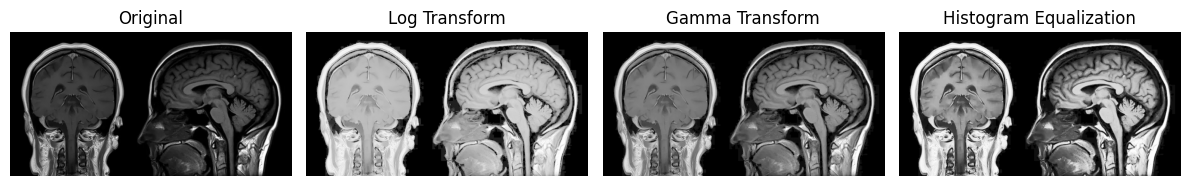

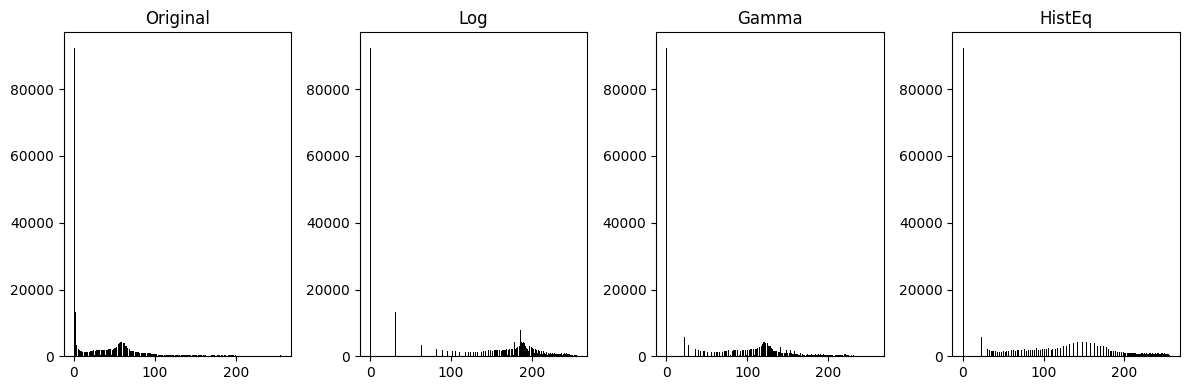

In [6]:
# Simulate a cell image (use MRI as example)
cell_img = cv2.imread('mri.jpeg', cv2.IMREAD_GRAYSCALE)
if cell_img is None:
    raise Exception('Image not found!')

# Log transformation
c = 255 / np.log(1 + np.max(cell_img))
log_cell = c * np.log(1 + cell_img.astype(np.float32))
log_cell = np.array(log_cell, dtype=np.uint8)

# Gamma transformation
gamma = 0.5
gamma_cell = np.array(255 * (cell_img / 255) ** gamma, dtype=np.uint8)

# Histogram equalization
hist_eq_cell = cv2.equalizeHist(cell_img)

# Plot images
plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
plt.imshow(cell_img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(log_cell, cmap='gray')
plt.title('Log Transform')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(gamma_cell, cmap='gray')
plt.title('Gamma Transform')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(hist_eq_cell, cmap='gray')
plt.title('Histogram Equalization')
plt.axis('off')
plt.tight_layout()
plt.show()

# Plot histograms
plt.figure(figsize=(12,4))
for i, im in enumerate([cell_img, log_cell, gamma_cell, hist_eq_cell]):
    plt.subplot(1,4,i+1)
    plt.hist(im.ravel(), bins=256, range=[0,256], color='black')
    plt.title(['Original','Log','Gamma','HistEq'][i])
plt.tight_layout()
plt.show()

### Observations: Biomedical Microscopic Image Enhancement

- **Log and gamma transformations** enhance small intensity variations, making cell boundaries more visible.
- **Histogram equalization** improves overall contrast but may not highlight fine details as effectively as log/gamma transforms.
- For fine detail enhancement, log/gamma transformations are preferred; histogram equalization is better for global contrast.
- Histogram plots and image comparison support these conclusions.